## Installing dependencies

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

## Importing Requirements and Loading Data

In [3]:
# essential supporting imports for data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

# essential sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# essential sklearn models imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# ignoring warnings
warnings.filterwarnings("ignore")

In [5]:
# loading the paysim dataset
data_set_path = 'D:/BIA Data Science & AI/Fraud Detection Project/Fraud Detection Dataset/Fraud_Analysis_Dataset.csv'
df = pd.read_csv(data_set_path)

## Data Inspection

In [7]:
# basic information of data to inspect if there are missing values
print("No of rowns, columns: ", df.shape)
df.head()
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nTarget distribution (isFraud):")
print(df['isFraud'].value_counts())
print(f"Fraud rate: {100 * df['isFraud'].mean():.6f}%")

No of rowns, columns:  (11142, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB

Missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

Target di

## Exploratory Data Analysis

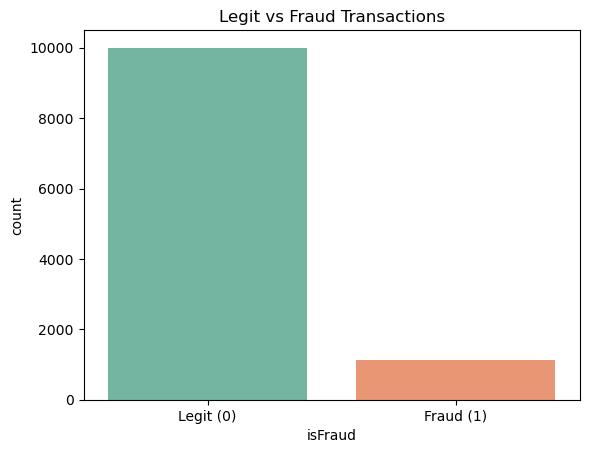

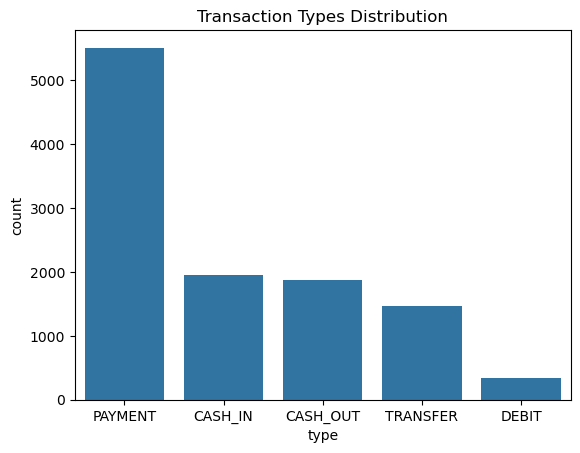


Fraud rate by transaction type:
type
TRANSFER    0.385246
CASH_OUT    0.308926
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


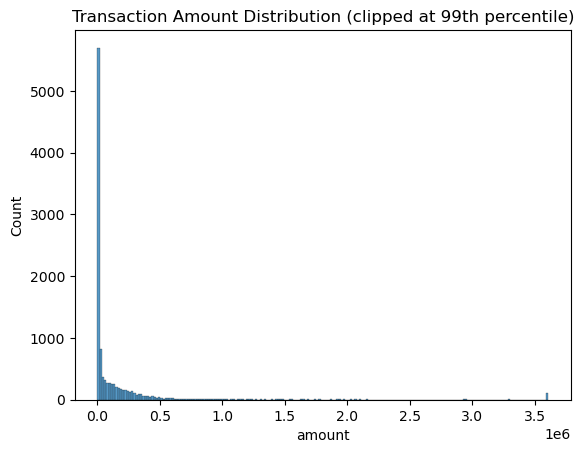

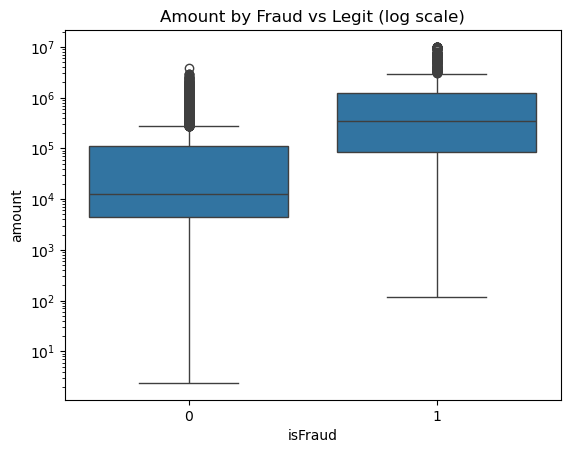

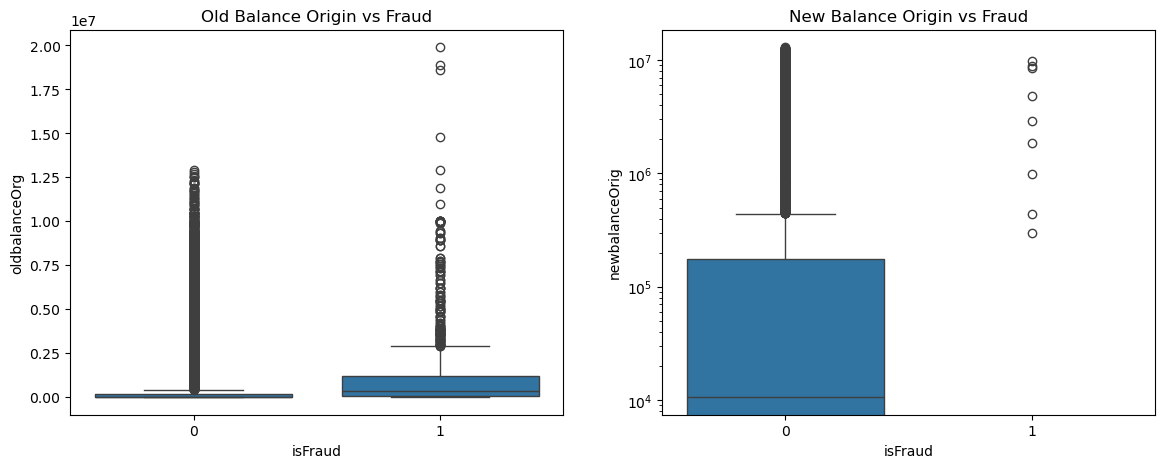

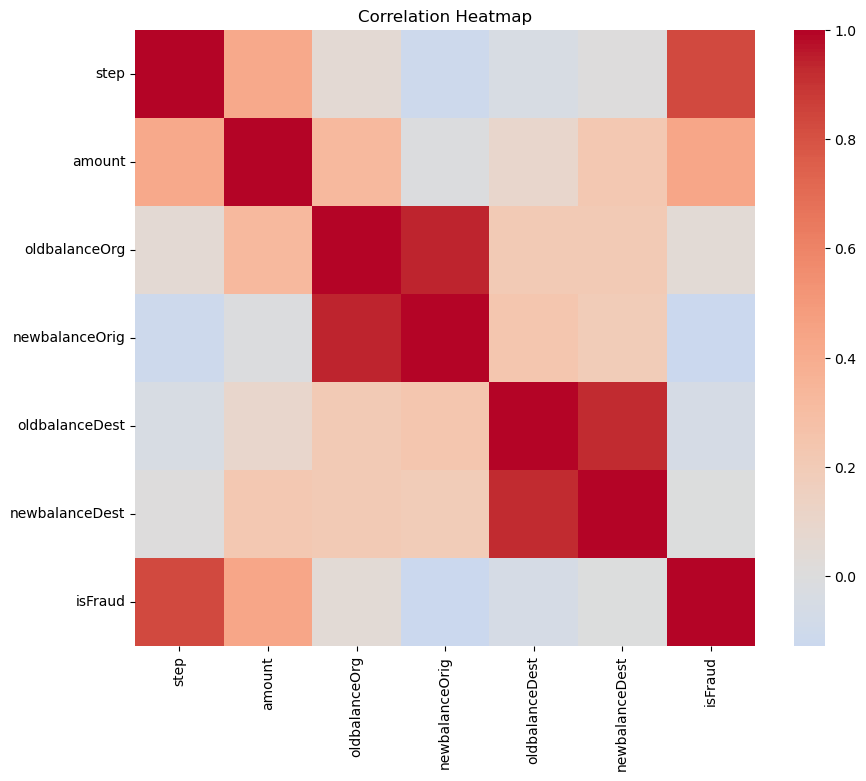

In [9]:
plt.figure()
sns.countplot(x='isFraud', data=df, palette='Set2')
plt.xticks([0,1], ['Legit (0)', 'Fraud (1)'])
plt.title("Legit vs Fraud Transactions")
plt.show()

# Transaction type distribution
plt.figure()
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title("Transaction Types Distribution")
plt.show()

# Fraud rate by type
print("\nFraud rate by transaction type:")
print(df.groupby('type')['isFraud'].mean().sort_values(ascending=False))

# Amount distribution (clipped at 99th percentile)
p99 = df['amount'].quantile(0.99)
plt.figure()
sns.histplot(df['amount'].clip(upper=p99), bins=200)
plt.title("Transaction Amount Distribution (clipped at 99th percentile)")
plt.show()

# Boxplot of amount by fraud
plt.figure()
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title("Amount by Fraud vs Legit (log scale)")
plt.show()

# Balance behavior
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(x='isFraud', y='oldbalanceOrg', data=df, ax=ax[0])
ax[0].set_title("Old Balance Origin vs Fraud")
sns.boxplot(x='isFraud', y='newbalanceOrig', data=df, ax=ax[1])
ax[1].set_title("New Balance Origin vs Fraud")
plt.yscale("log")
plt.show()

# Correlation heatmap
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

In [11]:
# dropping columns which are not required
df['type_encoded'] = LabelEncoder().fit_transform(df['type'])

# Select features
features = ['step', 'type_encoded', 'amount', 'oldbalanceOrg',
            'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

X = df[features]
y = df['isFraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training Fraud Cases:", sum(y_train))
print("Testing Fraud Cases:", sum(y_test))

Training Fraud Cases: 799
Testing Fraud Cases: 343


## Model Training

In [13]:
# scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression model training
logreg = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:,1]

In [15]:
# random forest model training
rf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced",
    max_depth=5, random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [17]:
# gradient boosting model training
gb = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=5, random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:,1]

In [19]:
# support vector machine model training
svm = SVC(
    kernel="rbf", class_weight="balanced",
    probability=True, random_state=42
)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:,1]

## Performance Evaulation

In [21]:
def evaluate_model(name, y_test, y_pred, y_proba):
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, digits=4))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*50)

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_proba_gb)
evaluate_model("SVM", y_test, y_pred_svm, y_proba_svm)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.9898    0.9990    0.9944      3000
           1     0.9905    0.9096    0.9483       343

    accuracy                         0.9898      3343
   macro avg     0.9901    0.9543    0.9713      3343
weighted avg     0.9898    0.9898    0.9896      3343

ROC-AUC: 0.9761253644314868
Confusion Matrix:
 [[2997    3]
 [  31  312]]
--------------------------------------------------
=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9960    1.0000    0.9980      3000
           1     1.0000    0.9650    0.9822       343

    accuracy                         0.9964      3343
   macro avg     0.9980    0.9825    0.9901      3343
weighted avg     0.9964    0.9964    0.9964      3343

ROC-AUC: 0.999620019436346
Confusion Matrix:
 [[3000    0]
 [  12  331]]
--------------------------------------------------
=== Gradient Boosting ===
              precisi

## Visualization of Model Performance

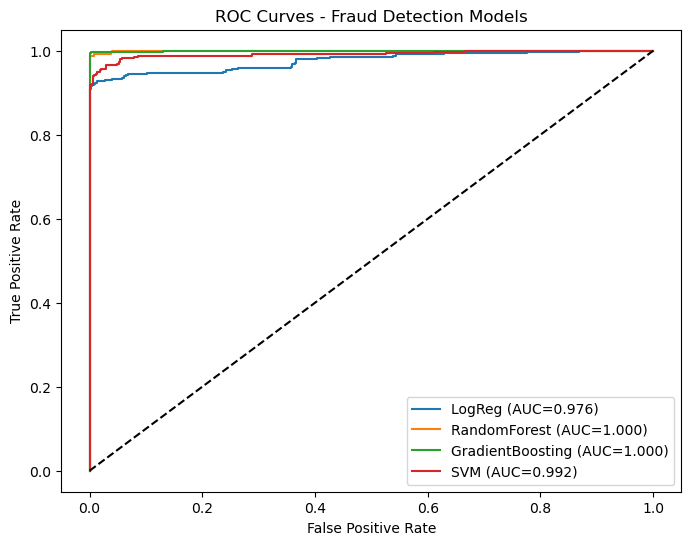

In [23]:
# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={roc_auc_score(y_test,y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={roc_auc_score(y_test,y_proba_rf):.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"GradientBoosting (AUC={roc_auc_score(y_test,y_proba_gb):.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={roc_auc_score(y_test,y_proba_svm):.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Fraud Detection Models")
plt.legend()
plt.show()

## Financial Impact Analysis

In [25]:
loss_per_fraud = df[df['isFraud']==1]['amount'].mean()

false_negatives = ((y_test==1) & (y_pred_rf==0)).sum()
false_positives = ((y_test==0) & (y_pred_rf==1)).sum()

expected_loss = false_negatives * loss_per_fraud
expected_cost = false_positives * 10  # assume investigation cost

print("\nFinancial Impact Analysis:")
print(f"Avg fraud transaction amount: {loss_per_fraud:.2f}")
print(f"False Negatives (missed frauds): {false_negatives}")
print(f"False Positives (legit flagged): {false_positives}")
print(f"Expected Loss: {expected_loss:.2f}")
print(f"Expected Investigation Cost: {expected_cost:.2f}")


Financial Impact Analysis:
Avg fraud transaction amount: 1192628.93
False Negatives (missed frauds): 12
False Positives (legit flagged): 0
Expected Loss: 14311547.18
Expected Investigation Cost: 0.00


## Explainability with SHAP

(1000, 7, 2)


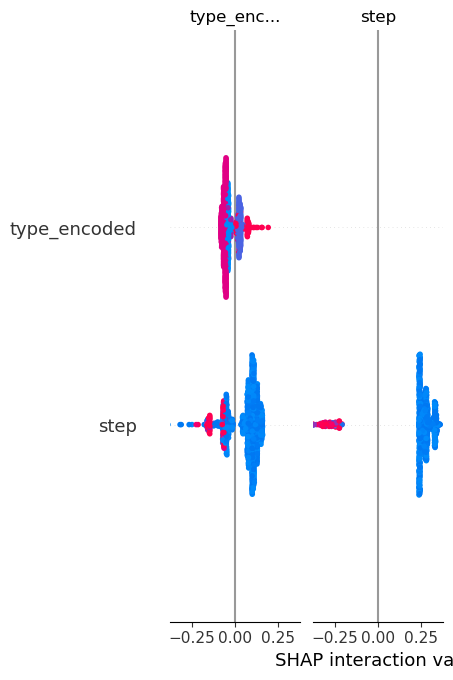

In [27]:
# Use SHAP for feature importance (Random Forest example)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_df[:1000])

# For binary classification, shap_values is a list with 2 arrays (class 0 and class 1)
print(shap_values.shape)   # should be (1000, 8)

shap.summary_plot(shap_values, X_test_df[:1000])